<a href="https://colab.research.google.com/github/SweetTooth05/Resume-Demo/blob/main/Unlabelled%20Supervised%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Importing Packages and Libraries


In [ ]:
# Load the libraries needed
import os
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , ReLU, Dropout, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, confusion_matrix, classification_report, silhouette_score, calinski_harabasz_score
import shutil
from tqdm import tqdm
from tensorflow.keras.models import Model
import torch
import torchvision.transforms as transforms
from PIL import Image

####Loading Images Function

In [ ]:
#load the images form the folder
def load_images_from_folder(folder):
    images = []
    filenames = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (150, 150)) #forcing images to a size in case some are not sized properly
            images.append(img)
            filenames.append(filename)
    return np.array(images), filenames

In [ ]:
def get_data(data_dir):
    cluster_labels = []
    i = 0
    while i < min_cluster:
        cluster_labels.append(str(i))  # convert int to str for folder names
        i += 1

    data = []
    for label in cluster_labels:
        path = os.path.join(data_dir, label)
        class_num = int(label)  # since label is a string, convert to int for class index
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img))
                if img_arr is None:
                    continue
                img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
                resized_arr = cv2.resize(img_arr, (150, 150))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")

    X = np.array([item[0] for item in data], dtype=object)
    y = np.array([item[1] for item in data])
    return X, y

In [ ]:
#Image Augmentation to Increase the Size of the Training Set
# Data augmentation function using torchvision transforms
def augment_images(images, labels, augmentation_factor=2):
    """
    Augment images using horizontal flipping and brightness changes
    Args:
        images: numpy array of images
        labels: corresponding labels
        augmentation_factor: how many augmented versions to create per image
    Returns:
        augmented_images: numpy array of original + augmented images
        augmented_labels: corresponding labels
    """
    print(f"Augmenting {len(images)} images with factor {augmentation_factor}...")

    try:
        # Try to use torchvision transforms
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
            transforms.ColorJitter(brightness=0.3, contrast=0.2),  # Brightness and contrast changes
            transforms.ToTensor()
        ])

        augmented_images = []
        augmented_labels = []

        # Add original images
        augmented_images.extend(images)
        augmented_labels.extend(labels)

        # Create augmented versions
        for i in tqdm(range(len(images)), desc="Creating augmented images"):
            img = images[i]
            label = labels[i]

            for _ in range(augmentation_factor):
                # Apply augmentation
                img_tensor = transform(img)
                # Convert back to numpy array and correct format
                img_augmented = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

                augmented_images.append(img_augmented)
                augmented_labels.append(label)

        print(f"Total images after augmentation: {len(augmented_images)}")
        return np.array(augmented_images), np.array(augmented_labels)

    except ImportError:
        print("Warning: torchvision not available. Using basic augmentation with OpenCV...")
        # Fallback to basic augmentation using OpenCV
        augmented_images = []
        augmented_labels = []

        # Add original images
        augmented_images.extend(images)
        augmented_labels.extend(labels)

        # Create augmented versions using OpenCV
        for i in tqdm(range(len(images)), desc="Creating augmented images (OpenCV)"):
            img = images[i]
            label = labels[i]

            for _ in range(augmentation_factor):
                # Horizontal flip
                if np.random.random() > 0.5:
                    img_augmented = cv2.flip(img, 1)
                else:
                    img_augmented = img.copy()

                # Brightness and contrast adjustment
                alpha = np.random.uniform(0.7, 1.3)  # Contrast
                beta = np.random.uniform(-30, 30)    # Brightness
                img_augmented = cv2.convertScaleAbs(img_augmented, alpha=alpha, beta=beta)

                augmented_images.append(img_augmented)
                augmented_labels.append(label)

        print(f"Total images after augmentation: {len(augmented_images)}")
        return np.array(augmented_images), np.array(augmented_labels)

####Performing Feature Extraction

In [ ]:
# Feature extraction using pre-trained ResNet50 model with batching
def extract_features(images, batch_size=32):
    model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    model.trainable = False
    features_list = []
    n_images = images.shape[0]
    for i in tqdm(range(0, n_images, batch_size), desc='Extracting features'):
        batch = images[i:i+batch_size].astype(np.float32)
        batch = resnet_preprocess_input(batch)
        features = model.predict(batch, verbose=0)
        features_list.append(features)
    features = np.concatenate(features_list, axis=0)
    return features

# Flatten the extracted features
def flatten_features(features):
    return features.reshape(features.shape[0], -1)

def davies_bouldin_method(features, max_clusters=20): #using the smallest global value within 20 clusters
    davies_bouldin_scores = [] # Initialize an empty list to store Davies-Bouldin scores for different cluster numbers.
    cluster_number = [] #saving the number of clusters
    for n_clusters in range(2, max_clusters + 1): # Loop through Cluster Numbers
        kmeans = KMeans(n_init='auto', n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(features)
        db_score = davies_bouldin_score(features, labels)
        davies_bouldin_scores.append(db_score)
        cluster_number.append(n_clusters) #storing the current cluster number in the list
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_clusters + 1), davies_bouldin_scores, marker='o')
    plt.xlabel('Number of clusters')
    plt.ylabel('Davies-Bouldin Index')
    plt.title('Davies-Bouldin Method')
    plt.xticks(range(2, max_clusters + 1))  # Set x-axis to show only integers
    plt.show()
    min_index = np.argmin(davies_bouldin_scores)
    return cluster_number[min_index]  # return the number of clusters with the minimum DBI

def evaluate_clustering_quality(features, labels):
    # Davies-Bouldin Index (lower is better)
    db_score = davies_bouldin_score(features, labels)

    # Silhouette Score (higher is better, range: -1 to 1)
    sil_score = silhouette_score(features, labels)

    # Calinski-Harabasz Index (higher is better)
    ch_score = calinski_harabasz_score(features, labels)

    print(f"Clustering Quality Metrics:")
    print(f"  Davies-Bouldin Index: {db_score:.3f} (lower is better)")
    print(f"  Silhouette Score: {sil_score:.3f} (higher is better, range: -1 to 1)")
    print(f"  Calinski-Harabasz Index: {ch_score:.3f} (higher is better)")

    return {
        'davies_bouldin': db_score,
        'silhouette': sil_score,
        'calinski_harabasz': ch_score
    }

####Iterative Model Clustering

In [ ]:
def build_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(16, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D()(x)
    x = Conv2D(32, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D()(x)
    x = Conv2D(32, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPool2D()(x)
    x = Dropout(0.5)(x)
    x = Flatten()(x)
    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.3)(x)
    features = x
    outputs = Dense(num_classes, activation='softmax')(features)
    model = Model(inputs, outputs)
    feature_model = Model(inputs, features)
    return model, feature_model

def extract_features_from_model(images, feature_model, batch_size=32, preprocess_fn=None):
    features_list = []
    n_images = images.shape[0]
    for i in tqdm(range(0, n_images, batch_size), desc='Extracting features'):
        batch = images[i:i+batch_size].astype(np.float32)
        if preprocess_fn is not None:
            batch = preprocess_fn(batch)
        features = feature_model.predict(batch, verbose=0)
        features_list.append(features)
    features = np.concatenate(features_list, axis=0)
    return features

def filter_high_confidence_predictions(model, images, confidence_threshold=0.7):
    # Get predictions for all images
    predictions = model.predict(images.astype(np.float32) / 255.0, verbose=0)

    # Calculate confidence scores (max probability)
    confidence_scores = np.max(predictions, axis=1)
    cluster_labels = np.argmax(predictions, axis=1)

    # Filter high confidence predictions
    high_conf_mask = confidence_scores >= confidence_threshold
    filtered_images = images[high_conf_mask]
    filtered_labels = cluster_labels[high_conf_mask]
    filtered_confidence = confidence_scores[high_conf_mask]

    print(f"Original images: {len(images)}")
    print(f"High confidence images: {len(filtered_images)} ({len(filtered_images)/len(images)*100:.1f}%)")
    print(f"Average confidence: {np.mean(filtered_confidence):.3f}")

    return filtered_images, filtered_labels, filtered_confidence

In [ ]:
#Found that an iterative clustring and training method would overfit the data too much and result in worse results
#Implementing an Early stop method to prevent unecessary epochs from overfitting the data
# Enhanced early stopping callback
class EnhancedEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', patience=5, min_delta=0.001, restore_best_weights=True):
        super(EnhancedEarlyStopping, self).__init__()
        self.monitor = monitor
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best = None
        self.wait = 0
        self.best_weights = None

    def on_train_begin(self, logs=None):
        self.wait = 0
        self.best = float('inf') if self.monitor == 'val_loss' else float('-inf')

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if self.monitor == 'val_loss':
            improved = current < self.best - self.min_delta
        else:
            improved = current > self.best + self.min_delta

        if improved:
            self.best = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)
                print(f'\nEarly stopping triggered after {epoch + 1} epochs')

####**Main Fucntion**

In [ ]:
# 1. Load and preprocess images
shutil.unpack_archive("product_images.zip", "/content/")
folder_path = '/content/product_images'
images, filenames = load_images_from_folder(folder_path)

In [ ]:
# 2. Initial feature extraction (ResNet50)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
resnet_model.trainable = False
feature_model = Model(inputs=resnet_model.input, outputs=resnet_model.output)
preprocess_fn = resnet_preprocess_input
features = extract_features_from_model(images, feature_model, batch_size=32, preprocess_fn=preprocess_fn)
flattened_features = flatten_features(features)

# 3. Dimensionality reduction
pca = PCA(n_components=50)
reduced_features = pca.fit_transform(flattened_features)

Extracting features: 100%|██████████| 75/75 [03:50<00:00,  3.08s/it]


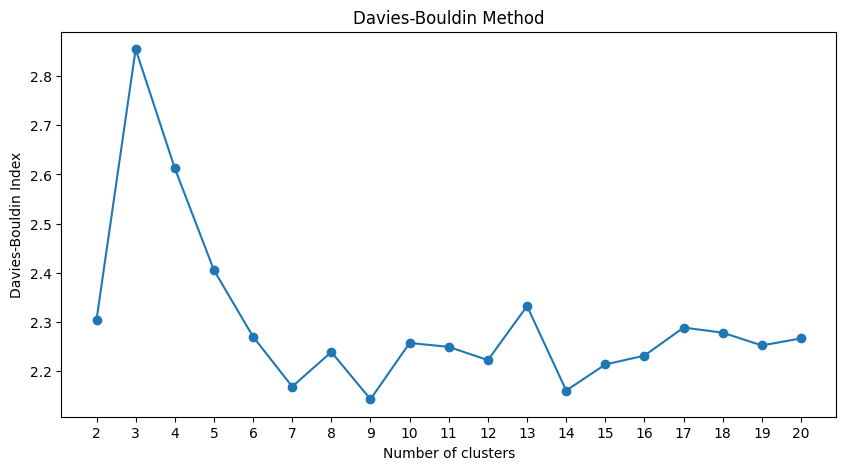


Initial Clustering Quality (ResNet50 + KMeans):
Clustering Quality Metrics:
  Davies-Bouldin Index: 2.142 (lower is better)
  Silhouette Score: 0.135 (higher is better, range: -1 to 1)
  Calinski-Harabasz Index: 201.184 (higher is better)


In [ ]:
# 4. Find optimal clusters
min_cluster = davies_bouldin_method(reduced_features)

# 5. KMeans clustering
kmeans = KMeans(n_clusters=min_cluster, n_init='auto', random_state=42)
labels = kmeans.fit_predict(reduced_features)

# Evaluate initial clustering quality
print("\nInitial Clustering Quality (ResNet50 + KMeans):")
initial_metrics = evaluate_clustering_quality(reduced_features, labels)

In [ ]:
# 6. Prepare DataFrames for splitting
import pandas as pd

df = pd.DataFrame({'Filename': filenames, 'Cluster': labels})
source_dir = 'product_images/'
train_dir = 'data_split/train/'
test_dir = 'data_split/test/'

X_train, X_test, y_train, y_test = train_test_split(
    df['Filename'], df['Cluster'],
    test_size=0.2, stratify=df['Cluster'], random_state=42
)
train_df = pd.DataFrame({'Filename': X_train, 'Cluster': y_train})
test_df = pd.DataFrame({'Filename': X_test, 'Cluster': y_test})

def copy_split_files(df_split, target_root):
    for _, row in df_split.iterrows():
        fname = row['Filename']
        label = str(row['Cluster'])
        src = os.path.join(source_dir, fname)
        dst_dir = os.path.join(target_root, label)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(src, os.path.join(dst_dir, fname))

copy_split_files(train_df, train_dir)
copy_split_files(test_df, test_dir)

In [ ]:
# 7. Iterative Self-Labelling (Deep Clustering)
N_ITER = 3  # Reduced iterations to prevent feedback loop issues
BATCH_SIZE = 32 #Training Image Batch Size
PCA_COMPONENTS = 50 #For Dimensionality Reduction
all_images = images #Image Data
confidence_threshold = 0.7  # Confidence threshold for filtering

for iteration in range(N_ITER):
    print(f"\n=== Iteration {iteration+1} ===")

    if iteration == 0:
        # First iteration: Use ResNet50 features + KMeans
        print("Initial clustering with ResNet50 features...")
        features = extract_features_from_model(all_images, feature_model, batch_size=BATCH_SIZE, preprocess_fn=preprocess_fn)
        features_flat = flatten_features(features)
        pca = PCA(n_components=PCA_COMPONENTS)
        reduced_features = pca.fit_transform(features_flat)
        n_clusters = min_cluster
        kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
        cluster_labels = kmeans.fit_predict(reduced_features)
        preprocess_fn = None  # Switch to CNN features for next iteration
    else:
        # Subsequent iterations: Use CNN features + confidence filtering
        print("Using CNN features with confidence filtering...")
        # Get predictions from previous model
        predictions = cnn_model.predict(all_images.astype(np.float32) / 255.0, verbose=0)
        cluster_labels = np.argmax(predictions, axis=1)

        # Filter high confidence predictions to reduce label noise
        filtered_images, filtered_labels, confidence_scores = filter_high_confidence_predictions(
            cnn_model, all_images, confidence_threshold
        )

        # Use filtered data for training
        X = filtered_images.astype(np.float32) / 255.0
        y = np.array(filtered_labels, dtype=np.int32)

        # If we have enough high-confidence samples, proceed with training
        if len(filtered_images) > n_clusters * 5:  # At least 5 samples per cluster
            print(f"Training on {len(filtered_images)} high-confidence samples...")
        else:
            print("Warning: Too few high-confidence samples. Using all data.")
            X = all_images.astype(np.float32) / 255.0
            y = np.array(cluster_labels, dtype=np.int32)

    # Prepare data for CNN training
    if iteration == 0:
        X = all_images.astype(np.float32) / 255.0
        y = np.array(cluster_labels, dtype=np.int32)
    else:
        # For subsequent iterations, use the filtered data
        X = filtered_images.astype(np.float32) / 255.0
        y = np.array(filtered_labels, dtype=np.int32)

    # Apply data augmentation to increase training set size and reduce overfitting
    print("Applying data augmentation...")
    X_augmented, y_augmented = augment_images(
        (X * 255).astype(np.uint8),
        y,
        augmentation_factor=2
    )
    X_augmented = X_augmented.astype(np.float32) / 255.0

    # Split augmented data
    X_train, X_test, y_train, y_test = train_test_split(
        X_augmented, y_augmented,
        test_size=0.2, stratify=y_augmented, random_state=42
    )

    print(f"Training set size after augmentation: {len(X_train)}")
    print(f"Test set size after augmentation: {len(X_test)}")

    # Build and train CNN with early stopping
    cnn_model, feature_model = build_cnn((150, 150, 3), n_clusters)
    opt = Adam(learning_rate=0.001)  # Reduced learning rate for stability

    # Add enhanced early stopping to prevent overfitting
    early_stopping = EnhancedEarlyStopping(
        monitor='val_loss',
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    )

    # Add learning rate reduction on plateau
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
    #Compiling the Model with the Accuracy Metric
    cnn_model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Training CNN on pseudo-labels with data augmentation...")
    history = cnn_model.fit( #fitting the model while recording the history
        X_train, y_train,
        epochs=15,  # Increased epochs since we have early stopping and data augmentation
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, lr_scheduler],
        verbose=2
    )

    np.save(f'cluster_labels_iter{iteration+1}.npy', cluster_labels)

    # Plot training history for the last iteration
    if iteration == N_ITER - 1:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='lower right')

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper right')
        plt.tight_layout()
        plt.show()

    print(f"Iteration {iteration+1} complete.\n")

print("Iterative self-labelling complete. Final model and clusters are available.")

# Final Model Evaluation
print("\nFinal Model Evaluation (after last iteration):")
final_predictions = cnn_model.predict(X_test)
final_predictions = np.argmax(final_predictions, axis=1)
print(confusion_matrix(y_test, final_predictions))
print(classification_report(y_test, final_predictions))

# Evaluate final clustering quality
print("\nFinal Clustering Quality (CNN Model):")
# Extract features from the final CNN model
final_features = feature_model.predict(all_images.astype(np.float32) / 255.0, verbose=0)
final_cluster_labels = cnn_model.predict(all_images.astype(np.float32) / 255.0, verbose=0)
final_cluster_labels = np.argmax(final_cluster_labels, axis=1)

final_metrics = evaluate_clustering_quality(final_features, final_cluster_labels)

# Compare initial vs final clustering quality
print("\nClustering Quality Comparison:")
print(f"Initial Davies-Bouldin: {initial_metrics['davies_bouldin']:.3f}")
print(f"Final Davies-Bouldin: {final_metrics['davies_bouldin']:.3f}")
print(f"Initial Silhouette: {initial_metrics['silhouette']:.3f}")
print(f"Final Silhouette: {final_metrics['silhouette']:.3f}")
print(f"Initial Calinski-Harabasz: {initial_metrics['calinski_harabasz']:.3f}")
print(f"Final Calinski-Harabasz: {final_metrics['calinski_harabasz']:.3f}")

# Final CNN Model Clustering Visualization
print("\nFinal CNN Model Clustering Visualization:")
# Get predictions for all images using the final CNN model
all_predictions = cnn_model.predict(all_images.astype(np.float32) / 255.0)
all_predictions = np.argmax(all_predictions, axis=1)

# Visualize clusters from final CNN model
for cluster in range(n_clusters):
    cluster_images = all_images[all_predictions == cluster]
    plt.figure(figsize=(15, 3))
    for i in range(min(len(cluster_images), 5)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(cluster_images[i])
        plt.axis('off')
    plt.suptitle(f'Final CNN Model - Cluster {cluster + 1}')
    plt.show()


=== Iteration 1 ===
Initial clustering with ResNet50 features...


Extracting features: 100%|██████████| 75/75 [03:45<00:00,  3.01s/it]


Applying data augmentation...
Augmenting 2400 images with factor 2...


Creating augmented images: 100%|██████████| 2400/2400 [00:05<00:00, 400.93it/s]


Total images after augmentation: 7200
Training set size after augmentation: 5760
Test set size after augmentation: 1440
Training CNN on pseudo-labels with data augmentation...
Epoch 1/15
180/180 - 174s - 964ms/step - accuracy: 0.4674 - loss: 1.6607 - val_accuracy: 0.1507 - val_loss: 2.7108 - learning_rate: 1.0000e-03
Epoch 2/15
180/180 - 200s - 1s/step - accuracy: 0.6663 - loss: 1.0392 - val_accuracy: 0.4368 - val_loss: 1.6109 - learning_rate: 1.0000e-03
Epoch 3/15


KeyboardInterrupt: 